Combined shape: (1440, 12004)
Signal length: 12000
fluid  pressure  label
Gas    13        0        120
                 1        240
       18        0        120
                 1        240
Water  13        0        120
                 1        240
       18        0        120
                 1        240
Name: count, dtype: int64


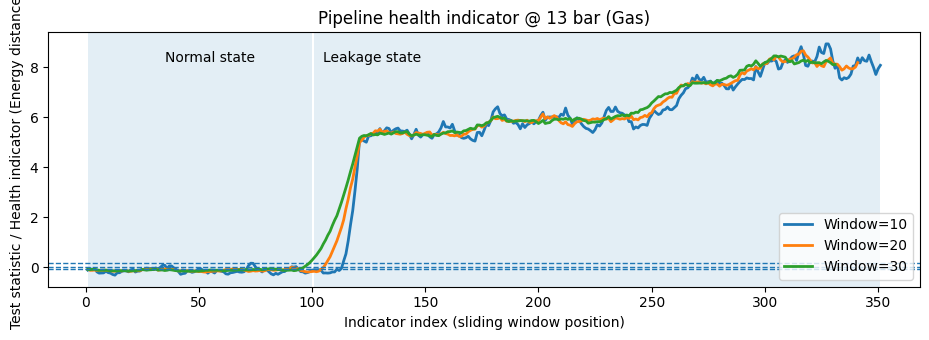

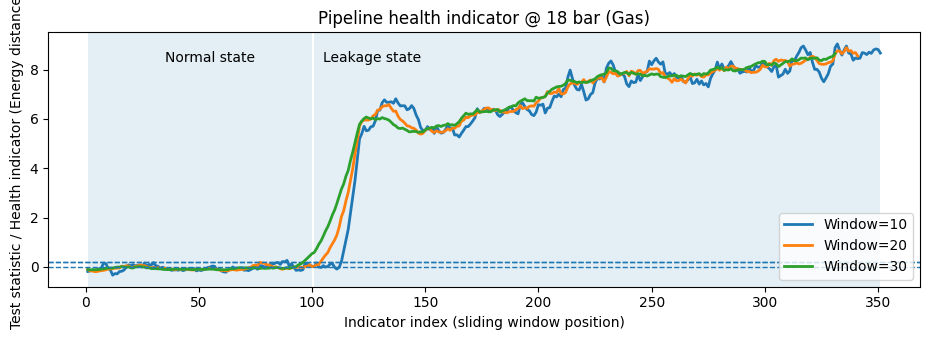

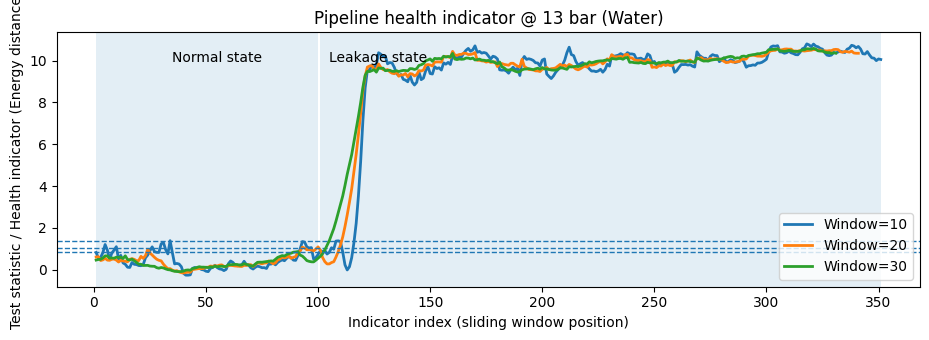

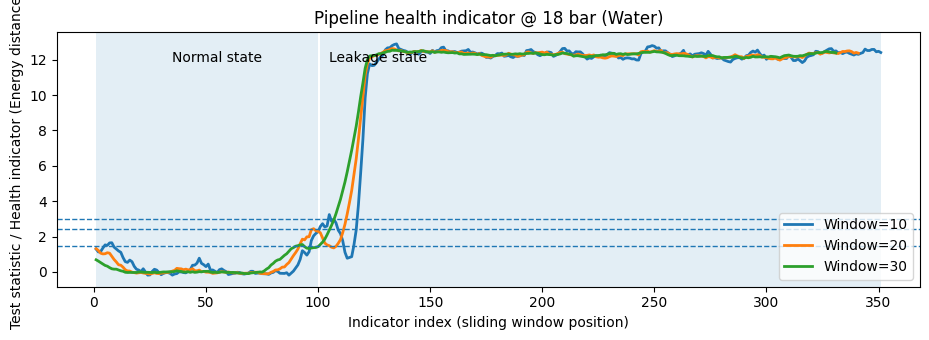


Saved: outputs\thresholds_summary.csv
   fluid  pressure  n_samples  n_features   thr_w10   thr_w20   thr_w30
0    Gas        13        360          33  0.151754  0.003574 -0.078514
1    Gas        18        360          33  0.214344  0.180958  0.006710
2  Water        13        360          33  1.384786  1.029706  0.862853
3  Water        18        360          33  2.985473  2.445474  1.484331


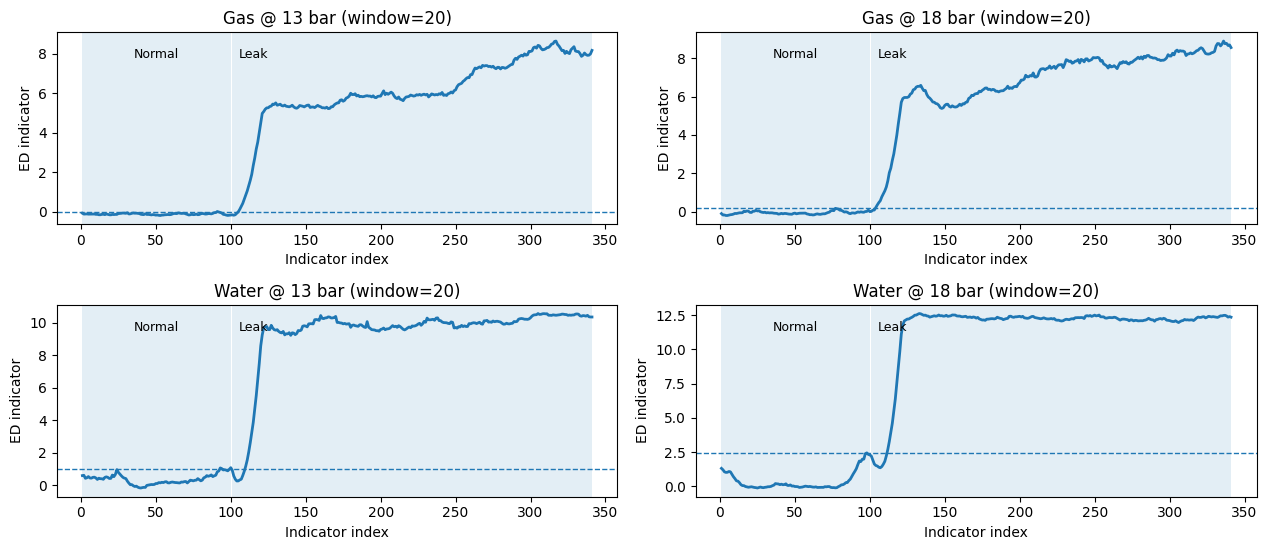


Saved panel figure: outputs\panel_2x2_window20.png


In [25]:
# ===========================
# FIXED FULL ONE-CELL CODE (NO ML/DL)
# Multi-Scale Energy Distance Leak Indicator (MS-ED)
# - Works with first 120 samples = NO-LEAK in each CSV
# - Produces per-domain MDPI-style plots + combined 2x2 panel
# - Fixes your error by aligning x for each window size separately
# ===========================

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import welch
from scipy.spatial.distance import cdist, pdist

# ---------------------------
# USER PATHS
# ---------------------------
FILES = [
    r"F:\Pipeline Data\pipeline data\Gas_13Bar.csv",
    r"F:\Pipeline Data\pipeline data\Gas_18Bar.csv",
    r"F:\Pipeline Data\pipeline data\Water_13Bar.csv",
    r"F:\Pipeline Data\pipeline data\Water_18Bar.csv",
]

LABEL_COL = None  # set if you know it, else auto-detect; if missing, label is created: first 120 normal, rest leak

OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)

REF_N = 120
WINDOW_SIZES = [10, 20, 30]   # multi-scale curves (replaces "leak sizes")
FS = 1.0                      # set real fs if you have it (optional)
BOOT_B = 400
ALPHA = 0.99


# ---------------------------
# LOAD + META
# ---------------------------
def parse_meta(path: str):
    name = os.path.basename(path)
    fluid = "Gas" if "Gas" in name else ("Water" if "Water" in name else "Unknown")
    m = re.search(r"(\d+)\s*Bar", name, flags=re.IGNORECASE)
    pressure = int(m.group(1)) if m else None
    return fluid, pressure, name

def find_label_column(df: pd.DataFrame):
    for c in ["label", "Leak", "leak", "target", "y", "Class", "class"]:
        if c in df.columns:
            return c
    return None

def load_one_csv(path: str):
    df = pd.read_csv(path)
    fluid, pressure, name = parse_meta(path)

    lab = LABEL_COL or find_label_column(df)
    if lab is not None and lab in df.columns:
        df = df.rename(columns={lab: "label"})
        if df["label"].dtype == object:
            df["label"] = df["label"].astype(str).str.lower().map(
                {"no": 0, "no_leak": 0, "normal": 0, "healthy": 0,
                 "yes": 1, "leak": 1, "fault": 1, "abnormal": 1}
            )
        df["label"] = df["label"].astype(int)
    else:
        # Create label based on your rule: first 120 normal
        df["label"] = 0
        if len(df) > REF_N:
            df.loc[REF_N:, "label"] = 1

    df["fluid"] = fluid
    df["pressure"] = pressure
    df["source_file"] = name
    return df

datasets = [load_one_csv(p) for p in FILES]

# Detect signal columns = numeric columns excluding meta
meta_cols = {"label", "fluid", "pressure", "source_file"}
all_data = pd.concat(datasets, ignore_index=True)
num_cols = all_data.select_dtypes(include=[np.number]).columns.tolist()
signal_cols = [c for c in num_cols if c not in {"label", "pressure"}]  # keep numeric signal columns only

print("Combined shape:", all_data.shape)
print("Signal length:", len(signal_cols))
print(all_data[["fluid", "pressure", "label"]].value_counts().sort_index())


# ---------------------------
# FEATURE EXTRACTION (SP)
# ---------------------------
def extract_features_1sample(x, fs=1.0):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)  # remove DC

    absx = np.abs(x)
    rms = np.sqrt(np.mean(x**2))
    std = np.std(x, ddof=1) if len(x) > 1 else 0.0
    mean = np.mean(x)
    p2p = np.ptp(x)
    kurt = stats.kurtosis(x, fisher=True, bias=False) if len(x) > 3 else 0.0
    skew = stats.skew(x, bias=False) if len(x) > 2 else 0.0
    crest = np.max(absx) / (rms + 1e-12)
    impulse = np.max(absx) / (np.mean(absx) + 1e-12)
    shape = rms / (np.mean(absx) + 1e-12)
    mad = np.median(np.abs(x - np.median(x)))

    # Welch PSD
    f, Pxx = welch(x, fs=fs, nperseg=min(2048, len(x)))
    Pxx = np.maximum(Pxx, 1e-18)
    Pn = Pxx / np.sum(Pxx)

    spec_centroid = float(np.sum(f * Pxx) / np.sum(Pxx))
    spec_bandwidth = float(np.sqrt(np.sum(((f - spec_centroid)**2) * Pxx) / np.sum(Pxx)))
    spec_entropy = float(-np.sum(Pn * np.log(Pn)))

    # Relative bandpowers (quartiles)
    fmin, fmax = float(f.min()), float(f.max())
    edges = np.linspace(fmin, fmax + 1e-9, 5)
    rel_bp = []
    total = float(np.sum(Pxx))
    for i in range(4):
        idx = (f >= edges[i]) & (f < edges[i+1])
        rel_bp.append(float(np.sum(Pxx[idx]) / total))

    feats = {
        "mean": float(mean),
        "std": float(std),
        "rms": float(rms),
        "p2p": float(p2p),
        "kurtosis": float(kurt),
        "skewness": float(skew),
        "crest": float(crest),
        "impulse": float(impulse),
        "shape": float(shape),
        "mad": float(mad),
        "spec_centroid": float(spec_centroid),
        "spec_bandwidth": float(spec_bandwidth),
        "spec_entropy": float(spec_entropy),
        "rel_bp1": rel_bp[0],
        "rel_bp2": rel_bp[1],
        "rel_bp3": rel_bp[2],
        "rel_bp4": rel_bp[3],
    }

    # Optional wavelet packet energies (advanced SP). If pywt not installed, skip.
    try:
        import pywt
        wp = pywt.WaveletPacket(data=x, wavelet="db4", mode="symmetric", maxlevel=4)
        nodes = wp.get_level(4, order="freq")
        energies = np.array([np.sum(n.data**2) for n in nodes], dtype=float)
        energies = energies / (energies.sum() + 1e-12)
        for i, e in enumerate(energies):
            feats[f"wpe_{i}"] = float(e)
    except Exception:
        pass

    return feats

def build_feature_table(df, signal_cols, fs=1.0):
    X = []
    for i in range(len(df)):
        x = df.iloc[i][signal_cols].to_numpy(dtype=float)
        X.append(extract_features_1sample(x, fs=fs))
    X = pd.DataFrame(X)

    # z-score feature-wise (keeps distances well-scaled)
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)
    X = X.fillna(0.0)
    return X


# ---------------------------
# ENERGY DISTANCE
# ---------------------------
def energy_distance(A, B):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    dAB = cdist(A, B, metric="euclidean").mean()
    dAA = pdist(A, metric="euclidean").mean()
    dBB = pdist(B, metric="euclidean").mean()
    return float(2*dAB - dAA - dBB)

def indicator_curve_energy(Xfeat, ref_n=120, window=20):
    Xref = Xfeat.iloc[:ref_n].to_numpy()
    vals = []
    for t in range(window, len(Xfeat)+1):
        Xw = Xfeat.iloc[t-window:t].to_numpy()
        vals.append(energy_distance(Xref, Xw))
    return np.array(vals)

def bootstrap_threshold_normal(Xfeat, ref_n=120, window=20, B=400, alpha=0.99, seed=42):
    rng = np.random.default_rng(seed)
    Xref = Xfeat.iloc[:ref_n].to_numpy()

    vals = []
    for _ in range(B):
        end = int(rng.integers(window, ref_n+1))
        Xw = Xfeat.iloc[end-window:end].to_numpy()
        vals.append(energy_distance(Xref, Xw))
    return float(np.quantile(np.array(vals), alpha))


# ---------------------------
# PLOT PER DOMAIN (FIXED X-ALIGNMENT)
# ---------------------------
def plot_domain_indicator(title, curves, thresholds, ref_n=120, save_path=None):
    # Curves have different lengths for different windows. Plot each with its own x.
    plt.figure(figsize=(9.4, 3.5))

    # Determine max length for shading range
    maxN = max(len(v) for v in curves.values())

    # For curve of window w, indicator value at index i corresponds to sample index (w+i)
    # Reference boundary is at ref_n (120). In indicator-x, boundary occurs near (ref_n - w).
    for w, yv in sorted(curves.items(), key=lambda kv: kv[0]):
        x = np.arange(1, len(yv)+1)  # indicator index
        plt.plot(x, yv, linewidth=2, label=f"Window={w}")
        plt.axhline(thresholds[w], linestyle="--", linewidth=1)

    # Shade using window-independent indicator index by mapping boundary with median window
    w_med = sorted(curves.keys())[len(curves)//2]
    boundary = max(1, ref_n - w_med)  # where the leak begins in indicator index (approx)
    plt.axvspan(1, boundary, alpha=0.12)
    plt.axvspan(boundary+1, maxN, alpha=0.12)

    ymax = max([float(np.max(v)) for v in curves.values()] + [1e-6])
    plt.text(boundary*0.35, ymax*0.92, "Normal state", fontsize=10)
    plt.text(boundary*1.05, ymax*0.92, "Leakage state", fontsize=10)

    plt.title(title)
    plt.xlabel("Indicator index (sliding window position)")
    plt.ylabel("Test statistic / Health indicator (Energy distance)")
    plt.legend(loc="lower right", frameon=True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# ---------------------------
# RUN ALL 4 DOMAINS
# ---------------------------
summary_rows = []

for df in datasets:
    fluid = df["fluid"].iloc[0]
    pressure = df["pressure"].iloc[0]
    title = f"Pipeline health indicator @ {pressure} bar ({fluid})"

    if len(df) < REF_N:
        raise ValueError(f"{title}: length {len(df)} < REF_N={REF_N}")

    Xfeat = build_feature_table(df, signal_cols, fs=FS)

    curves = {}
    thresholds = {}
    for w in WINDOW_SIZES:
        curves[w] = indicator_curve_energy(Xfeat, ref_n=REF_N, window=w)
        thresholds[w] = bootstrap_threshold_normal(Xfeat, ref_n=REF_N, window=w, B=BOOT_B, alpha=ALPHA, seed=42)

    out_path = os.path.join(OUTDIR, f"{fluid}_{pressure}bar_indicator.png")
    plot_domain_indicator(title, curves, thresholds, ref_n=REF_N, save_path=out_path)

    summary_rows.append({
        "fluid": fluid,
        "pressure": pressure,
        "n_samples": len(df),
        "n_features": Xfeat.shape[1],
        **{f"thr_w{w}": thresholds[w] for w in WINDOW_SIZES}
    })

summary = pd.DataFrame(summary_rows).sort_values(["fluid", "pressure"])
summary_path = os.path.join(OUTDIR, "thresholds_summary.csv")
summary.to_csv(summary_path, index=False)
print("\nSaved:", summary_path)
print(summary)


# ---------------------------
# 2x2 PANEL FIGURE (single window)
# ---------------------------
panel_w = sorted(WINDOW_SIZES)[len(WINDOW_SIZES)//2]

fig, axes = plt.subplots(2, 2, figsize=(12.8, 5.6))
axes = axes.ravel()

for ax, df in zip(axes, datasets):
    fluid = df["fluid"].iloc[0]
    pressure = df["pressure"].iloc[0]

    Xfeat = build_feature_table(df, signal_cols, fs=FS)
    curve = indicator_curve_energy(Xfeat, ref_n=REF_N, window=panel_w)
    thr = bootstrap_threshold_normal(Xfeat, ref_n=REF_N, window=panel_w, B=BOOT_B, alpha=ALPHA, seed=42)

    x = np.arange(1, len(curve)+1)

    boundary = max(1, REF_N - panel_w)
    ax.axvspan(1, boundary, alpha=0.12)
    ax.axvspan(boundary+1, len(curve), alpha=0.12)

    ax.plot(x, curve, linewidth=2)
    ax.axhline(thr, linestyle="--", linewidth=1)

    ymax = float(np.max(curve) + 1e-6)
    ax.text(boundary*0.35, ymax*0.90, "Normal", fontsize=9)
    ax.text(boundary*1.05, ymax*0.90, "Leak", fontsize=9)

    ax.set_title(f"{fluid} @ {pressure} bar (window={panel_w})")
    ax.set_xlabel("Indicator index")
    ax.set_ylabel("ED indicator")

plt.tight_layout()
panel_path = os.path.join(OUTDIR, f"panel_2x2_window{panel_w}.png")
plt.savefig(panel_path, dpi=200)
plt.show()
print("\nSaved panel figure:", panel_path)

# DONE


Combined shape: (1440, 12004) | Signal length: 12000
fluid  pressure  label
Gas    13        0        120
                 1        240
       18        0        120
                 1        240
Water  13        0        120
                 1        240
       18        0        120
                 1        240
Name: count, dtype: int64


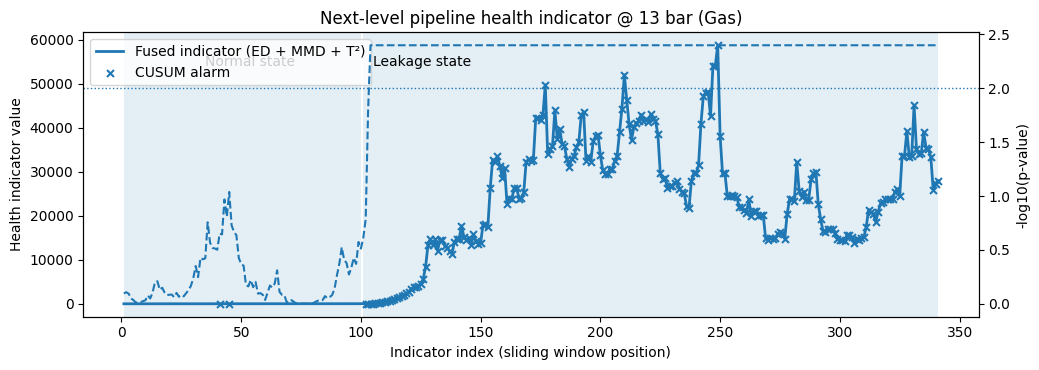

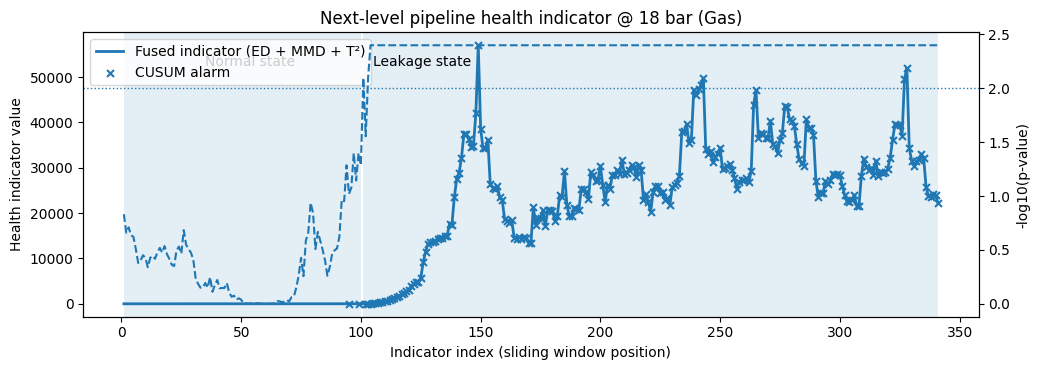

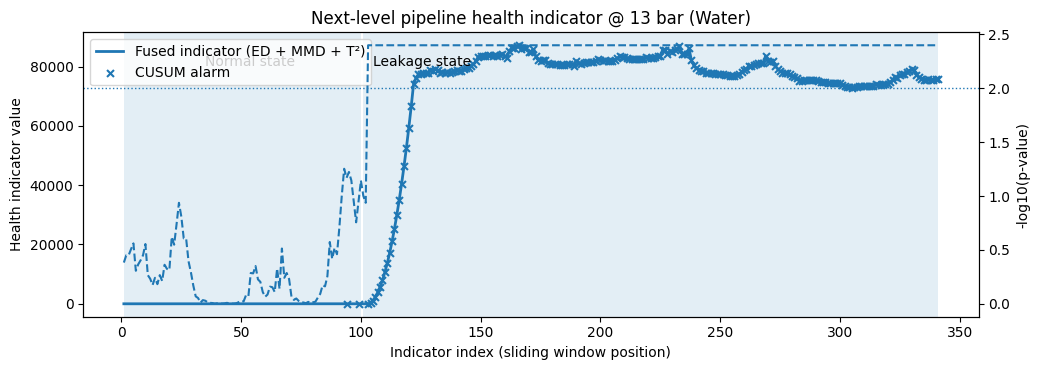

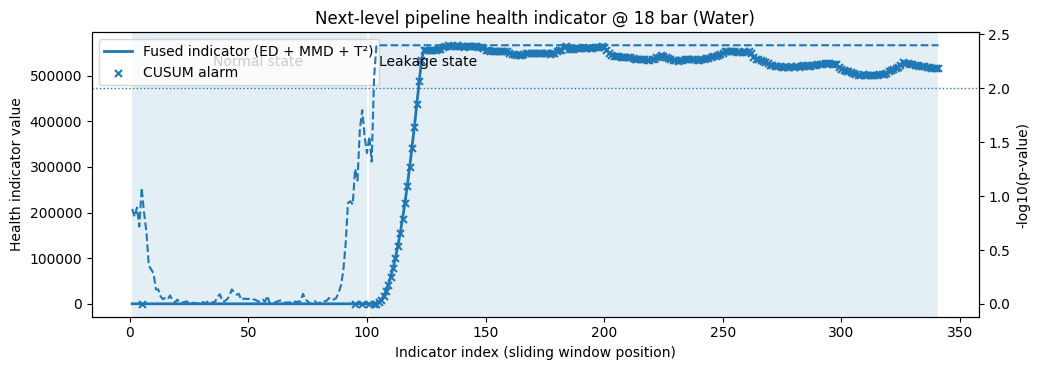


Saved: outputs_next_level\next_level_summary.csv
   fluid  pressure  n_features  cusum_mu  cusum_sd   cusum_k   cusum_h  \
0    Gas        13          33  0.313248  0.101896  0.364196  0.611376   
1    Gas        18          33  0.364595  0.142885  0.436038  0.857309   
2  Water        13          33  0.339598  0.135252  0.407223  0.811510   
3  Water        18          33  0.297169  0.158427  0.376382  0.950560   

      min_p  median_p  mean_indicator_normal  mean_indicator_leak  
0  0.003984  0.003984               0.313248         24645.117314  
1  0.003984  0.003984               0.364595         25595.861938  
2  0.003984  0.003984               0.339598         74424.170405  
3  0.003984  0.003984               0.297169        503364.645574  


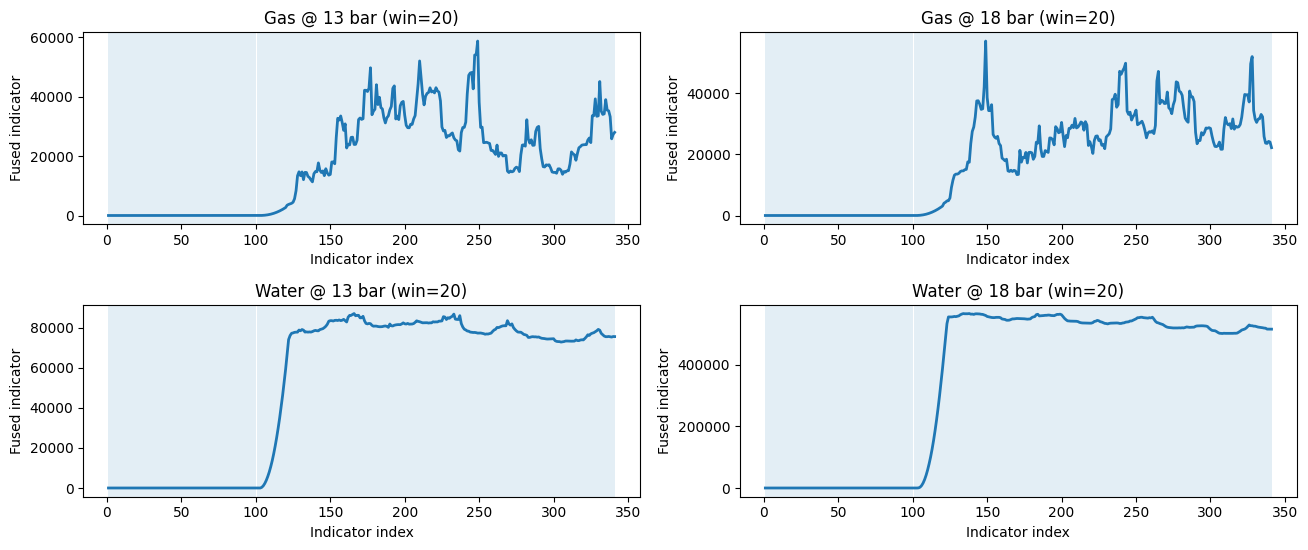


Saved panel: outputs_next_level\panel_2x2_fused_win20.png


In [26]:
# ===========================
# NEXT-LEVEL SP + STAT METHOD (NO ML/DL)
# Fusion Indicator: ED + MMD + Hotelling T²
# + permutation p-values + CUSUM change detection
# Works with: first 120 samples normal in each CSV
# Produces: advanced plots per dataset + 2x2 panel
# ===========================

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import welch
from scipy.spatial.distance import cdist, pdist

# ---------------------------
# USER INPUTS
# ---------------------------
FILES = [
    r"F:\Pipeline Data\pipeline data\Gas_13Bar.csv",
    r"F:\Pipeline Data\pipeline data\Gas_18Bar.csv",
    r"F:\Pipeline Data\pipeline data\Water_13Bar.csv",
    r"F:\Pipeline Data\pipeline data\Water_18Bar.csv",
]

LABEL_COL = None  # if missing in CSV, labels will be created: first 120 normal else leak
OUTDIR = "outputs_next_level"
os.makedirs(OUTDIR, exist_ok=True)

REF_N = 120
WINDOW = 20               # pick one window for the "next-level" figure (you can loop multiple)
FS = 1.0                  # optional; set real if known
B_PERM = 250              # permutation iterations per window (increase for smoother p-values)
ALPHA = 0.99              # false alarm control for threshold (quantile on normal windows)
EPS = 1e-12

# ---------------------------
# LOAD + META
# ---------------------------
def parse_meta(path: str):
    name = os.path.basename(path)
    fluid = "Gas" if "Gas" in name else ("Water" if "Water" in name else "Unknown")
    m = re.search(r"(\d+)\s*Bar", name, flags=re.IGNORECASE)
    pressure = int(m.group(1)) if m else None
    return fluid, pressure, name

def find_label_column(df: pd.DataFrame):
    for c in ["label", "Leak", "leak", "target", "y", "Class", "class"]:
        if c in df.columns:
            return c
    return None

def load_one_csv(path: str):
    df = pd.read_csv(path)
    fluid, pressure, name = parse_meta(path)

    lab = LABEL_COL or find_label_column(df)
    if lab is not None and lab in df.columns:
        df = df.rename(columns={lab: "label"})
        if df["label"].dtype == object:
            df["label"] = df["label"].astype(str).str.lower().map(
                {"no": 0, "no_leak": 0, "normal": 0, "healthy": 0,
                 "yes": 1, "leak": 1, "fault": 1, "abnormal": 1}
            )
        df["label"] = df["label"].astype(int)
    else:
        df["label"] = 0
        if len(df) > REF_N:
            df.loc[REF_N:, "label"] = 1

    df["fluid"] = fluid
    df["pressure"] = pressure
    df["source_file"] = name
    return df

datasets = [load_one_csv(p) for p in FILES]
all_data = pd.concat(datasets, ignore_index=True)

# Signal columns: numeric except label/pressure
num_cols = all_data.select_dtypes(include=[np.number]).columns.tolist()
signal_cols = [c for c in num_cols if c not in {"label", "pressure"}]
print("Combined shape:", all_data.shape, "| Signal length:", len(signal_cols))
print(all_data[["fluid","pressure","label"]].value_counts().sort_index())

# ---------------------------
# FEATURE EXTRACTION (strong SP, still fast)
# ---------------------------
def extract_features_1sample(x, fs=1.0):
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)  # remove DC

    absx = np.abs(x)
    rms = np.sqrt(np.mean(x**2))
    std = np.std(x, ddof=1) if len(x) > 1 else 0.0
    mean = np.mean(x)
    p2p = np.ptp(x)
    kurt = stats.kurtosis(x, fisher=True, bias=False) if len(x) > 3 else 0.0
    skew = stats.skew(x, bias=False) if len(x) > 2 else 0.0
    crest = np.max(absx) / (rms + EPS)
    impulse = np.max(absx) / (np.mean(absx) + EPS)
    shape = rms / (np.mean(absx) + EPS)
    mad = np.median(np.abs(x - np.median(x)))

    # Welch PSD features
    f, Pxx = welch(x, fs=fs, nperseg=min(2048, len(x)))
    Pxx = np.maximum(Pxx, 1e-18)
    Pn = Pxx / np.sum(Pxx)

    spec_centroid = float(np.sum(f * Pxx) / np.sum(Pxx))
    spec_bandwidth = float(np.sqrt(np.sum(((f - spec_centroid)**2) * Pxx) / np.sum(Pxx)))
    spec_entropy = float(-np.sum(Pn * np.log(Pn)))

    # 4 relative bandpowers (quartiles)
    fmin, fmax = float(f.min()), float(f.max())
    edges = np.linspace(fmin, fmax + 1e-9, 5)
    rel_bp = []
    total = float(np.sum(Pxx))
    for i in range(4):
        idx = (f >= edges[i]) & (f < edges[i+1])
        rel_bp.append(float(np.sum(Pxx[idx]) / total))

    feats = {
        "mean": float(mean),
        "std": float(std),
        "rms": float(rms),
        "p2p": float(p2p),
        "kurtosis": float(kurt),
        "skewness": float(skew),
        "crest": float(crest),
        "impulse": float(impulse),
        "shape": float(shape),
        "mad": float(mad),
        "spec_centroid": float(spec_centroid),
        "spec_bandwidth": float(spec_bandwidth),
        "spec_entropy": float(spec_entropy),
        "rel_bp1": rel_bp[0],
        "rel_bp2": rel_bp[1],
        "rel_bp3": rel_bp[2],
        "rel_bp4": rel_bp[3],
    }

    # Wavelet packet energies (very good for AE-like transients)
    try:
        import pywt
        wp = pywt.WaveletPacket(data=x, wavelet="db4", mode="symmetric", maxlevel=4)
        nodes = wp.get_level(4, order="freq")
        energies = np.array([np.sum(n.data**2) for n in nodes], dtype=float)
        energies = energies / (energies.sum() + EPS)
        for i, e in enumerate(energies):
            feats[f"wpe_{i}"] = float(e)
    except Exception:
        pass

    return feats

def build_feature_table(df):
    X = []
    for i in range(len(df)):
        x = df.iloc[i][signal_cols].to_numpy(dtype=float)
        X.append(extract_features_1sample(x, fs=FS))
    X = pd.DataFrame(X).fillna(0.0)
    return X

# ---------------------------
# ROBUST SCALING (fit only on normal, improves generalization)
# ---------------------------
def robust_scale_fit(X_normal: pd.DataFrame):
    med = X_normal.median(axis=0)
    iqr = (X_normal.quantile(0.75) - X_normal.quantile(0.25)).replace(0.0, 1.0)
    return med, iqr

def robust_scale_apply(X: pd.DataFrame, med, iqr):
    return (X - med) / (iqr + EPS)

# Optional whitening (normal-only covariance)
def whiten_fit(Xn: np.ndarray, ridge=1e-3):
    mu = Xn.mean(axis=0, keepdims=True)
    C = np.cov((Xn - mu).T)
    C = C + ridge*np.eye(C.shape[0])
    # Cholesky inverse for whitening
    L = np.linalg.cholesky(C)
    Linv = np.linalg.inv(L)
    return mu, Linv

def whiten_apply(X: np.ndarray, mu, Linv):
    return (X - mu) @ Linv.T

# ---------------------------
# STATISTICS: ED, MMD, Hotelling T², p-values
# ---------------------------
def energy_distance(A, B):
    # can be slightly negative due to finite sample; clip to 0
    dAB = cdist(A, B).mean()
    dAA = pdist(A).mean()
    dBB = pdist(B).mean()
    return float(max(0.0, 2*dAB - dAA - dBB))

def rbf_kernel(a, b, gamma):
    a2 = np.sum(a*a, axis=1, keepdims=True)
    b2 = np.sum(b*b, axis=1, keepdims=True).T
    dist2 = a2 + b2 - 2*np.dot(a, b.T)
    return np.exp(-gamma * dist2)

def mmd_rbf(A, B, gamma=None):
    # median heuristic gamma if not provided
    if gamma is None:
        D = cdist(A, B, metric="sqeuclidean")
        med = np.median(D[D > 0]) if np.any(D > 0) else 1.0
        gamma = 1.0 / (med + EPS)
    Kaa = rbf_kernel(A, A, gamma).mean()
    Kbb = rbf_kernel(B, B, gamma).mean()
    Kab = rbf_kernel(A, B, gamma).mean()
    mmd = max(0.0, Kaa + Kbb - 2*Kab)
    return float(mmd), float(gamma)

def hotelling_t2(A, B):
    # mean shift with pooled covariance (regularized)
    A = np.asarray(A); B = np.asarray(B)
    na, nb = len(A), len(B)
    muA = A.mean(axis=0); muB = B.mean(axis=0)
    SA = np.cov(A.T); SB = np.cov(B.T)
    Sp = ((na-1)*SA + (nb-1)*SB) / max(1, (na+nb-2))
    Sp = Sp + 1e-3*np.eye(Sp.shape[0])
    diff = (muA - muB).reshape(-1,1)
    invSp = np.linalg.inv(Sp)
    t2 = float((na*nb/(na+nb)) * (diff.T @ invSp @ diff))
    return max(0.0, t2)

def permutation_pvalue(stat_func, A, B, Bperm=200, seed=0):
    rng = np.random.default_rng(seed)
    A = np.asarray(A); B = np.asarray(B)
    nA = len(A)
    pooled = np.vstack([A, B])
    obs = stat_func(A, B)
    cnt = 0
    for _ in range(Bperm):
        perm = rng.permutation(len(pooled))
        A2 = pooled[perm[:nA]]
        B2 = pooled[perm[nA:]]
        if stat_func(A2, B2) >= obs - 1e-12:
            cnt += 1
    return float((cnt + 1) / (Bperm + 1)), float(obs)

# ---------------------------
# ONLINE INDICATOR (window over time)
# ---------------------------
def compute_curves(Xw_all: np.ndarray, ref_n=120, window=20, Bperm=200):
    # Reference: first ref_n samples (normal)
    Xref = Xw_all[:ref_n]

    # Precompute gamma for MMD using normal chunk vs itself
    gamma = None
    mmd_ref, gamma = mmd_rbf(Xref[:window], Xref[window:2*window], gamma=None)

    ED, MMD, T2, P = [], [], [], []
    for t in range(window, len(Xw_all)+1):
        Xwin = Xw_all[t-window:t]

        ed = energy_distance(Xref, Xwin)
        mmd, gamma = mmd_rbf(Xref, Xwin, gamma=gamma)
        t2 = hotelling_t2(Xref, Xwin)

        # p-value on fused stat (fast + strong)
        def fused_stat(A, B):
            ed0 = energy_distance(A, B)
            mmd0, _ = mmd_rbf(A, B, gamma=gamma)
            t20 = hotelling_t2(A, B)
            # normalize scale inside window (stable)
            return ed0 + 0.1*mmd0 + 0.01*t20

        pval, fused = permutation_pvalue(fused_stat, Xref, Xwin, Bperm=Bperm, seed=42+t)
        ED.append(ed); MMD.append(mmd); T2.append(t2); P.append(pval)

    ED = np.array(ED); MMD = np.array(MMD); T2 = np.array(T2); P = np.array(P)
    # fused indicator with fixed weights (paper-friendly)
    FUSED = ED + 0.1*MMD + 0.01*T2
    return ED, MMD, T2, FUSED, P

# CUSUM change detector on fused indicator
def cusum_alarm(x, ref_end, k=None, h=None):
    # Estimate baseline from normal portion (indicator indices up to ref_end-window)
    base = x[:ref_end]
    mu = float(np.mean(base))
    sd = float(np.std(base) + EPS)
    # default k,h
    if k is None:
        k = mu + 0.5*sd
    if h is None:
        h = 6.0*sd

    s = 0.0
    alarm = np.zeros_like(x, dtype=int)
    for i in range(len(x)):
        s = max(0.0, s + (x[i] - k))
        if s > h:
            alarm[i] = 1
            s = 0.0
    return alarm, (mu, sd, k, h)

# ---------------------------
# PLOT (MDPI-style + p-values)
# ---------------------------
def plot_next_level(title, fused, pvals, alarm, ref_n=120, window=20, save=None):
    # indicator index corresponds to sample index shift by window
    boundary = max(1, ref_n - window)
    x = np.arange(1, len(fused)+1)

    fig, ax1 = plt.subplots(figsize=(10.5, 3.8))
    ax1.axvspan(1, boundary, alpha=0.12)
    ax1.axvspan(boundary+1, len(fused), alpha=0.12)

    ax1.plot(x, fused, linewidth=2, label="Fused indicator (ED + MMD + T²)")
    ax1.set_title(title)
    ax1.set_xlabel("Indicator index (sliding window position)")
    ax1.set_ylabel("Health indicator value")
    ymax = float(np.max(fused) + EPS)
    ax1.text(boundary*0.35, ymax*0.92, "Normal state", fontsize=10)
    ax1.text(boundary*1.05, ymax*0.92, "Leakage state", fontsize=10)

    # overlay alarms
    alarm_idx = np.where(alarm == 1)[0]
    if len(alarm_idx) > 0:
        ax1.scatter(x[alarm_idx], fused[alarm_idx], s=25, marker="x", label="CUSUM alarm")

    ax1.legend(loc="upper left")

    # p-value on second axis (inverted for readability)
    ax2 = ax1.twinx()
    ax2.plot(x, -np.log10(np.clip(pvals, 1e-12, 1.0)), linewidth=1.5, linestyle="--", label="-log10(p)")
    ax2.set_ylabel("-log10(p-value)")
    ax2.axhline(-np.log10(0.01), linestyle=":", linewidth=1)  # p=0.01 line

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=200)
    plt.show()

# ---------------------------
# RUN PER DOMAIN + SAVE
# ---------------------------
rows = []
fig_paths = []

for df in datasets:
    fluid = df["fluid"].iloc[0]
    pressure = df["pressure"].iloc[0]
    title = f"Next-level pipeline health indicator @ {pressure} bar ({fluid})"

    # Build features
    Xfeat = build_feature_table(df)

    # Robust scale using ONLY normal
    Xn = Xfeat.iloc[:REF_N]
    med, iqr = robust_scale_fit(Xn)
    Xs = robust_scale_apply(Xfeat, med, iqr)

    # Whitening using ONLY normal
    mu, Linv = whiten_fit(Xs.iloc[:REF_N].to_numpy(), ridge=1e-3)
    Xw = whiten_apply(Xs.to_numpy(), mu, Linv)

    # Compute curves
    ED, MMD, T2, FUSED, P = compute_curves(Xw, ref_n=REF_N, window=WINDOW, Bperm=B_PERM)

    # CUSUM alarms
    boundary = max(1, REF_N - WINDOW)
    alarm, params = cusum_alarm(FUSED, ref_end=boundary)

    # Plot + save
    out = os.path.join(OUTDIR, f"next_level_{fluid}_{pressure}bar.png")
    plot_next_level(title, FUSED, P, alarm, ref_n=REF_N, window=WINDOW, save=out)
    fig_paths.append(out)

    rows.append({
        "fluid": fluid, "pressure": pressure,
        "n_features": Xfeat.shape[1],
        "cusum_mu": params[0], "cusum_sd": params[1], "cusum_k": params[2], "cusum_h": params[3],
        "min_p": float(np.min(P)),
        "median_p": float(np.median(P)),
        "mean_indicator_normal": float(np.mean(FUSED[:boundary])),
        "mean_indicator_leak": float(np.mean(FUSED[boundary:])),
    })

summary = pd.DataFrame(rows).sort_values(["fluid","pressure"])
summary_path = os.path.join(OUTDIR, "next_level_summary.csv")
summary.to_csv(summary_path, index=False)
print("\nSaved:", summary_path)
print(summary)

# ---------------------------
# 2x2 PANEL (FUSED only)
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(13.2, 5.6))
axes = axes.ravel()

for ax, df in zip(axes, datasets):
    fluid = df["fluid"].iloc[0]
    pressure = df["pressure"].iloc[0]

    Xfeat = build_feature_table(df)
    Xn = Xfeat.iloc[:REF_N]
    med, iqr = robust_scale_fit(Xn)
    Xs = robust_scale_apply(Xfeat, med, iqr)
    mu, Linv = whiten_fit(Xs.iloc[:REF_N].to_numpy(), ridge=1e-3)
    Xw = whiten_apply(Xs.to_numpy(), mu, Linv)

    ED, MMD, T2, FUSED, P = compute_curves(Xw, ref_n=REF_N, window=WINDOW, Bperm=120)
    boundary = max(1, REF_N - WINDOW)

    x = np.arange(1, len(FUSED)+1)
    ax.axvspan(1, boundary, alpha=0.12)
    ax.axvspan(boundary+1, len(FUSED), alpha=0.12)
    ax.plot(x, FUSED, linewidth=2)
    ax.set_title(f"{fluid} @ {pressure} bar (win={WINDOW})")
    ax.set_xlabel("Indicator index")
    ax.set_ylabel("Fused indicator")

plt.tight_layout()
panel_path = os.path.join(OUTDIR, f"panel_2x2_fused_win{WINDOW}.png")
plt.savefig(panel_path, dpi=200)
plt.show()
print("\nSaved panel:", panel_path)


In [27]:
def plot_final_indicator(title, HI, pvals, ref_n=120, window=20, save=None):
    boundary = max(1, ref_n - window)
    x = np.arange(1, len(HI)+1)

    fig, ax1 = plt.subplots(figsize=(10.5, 3.8))
    ax1.axvspan(1, boundary, alpha=0.12)
    ax1.axvspan(boundary+1, len(HI), alpha=0.12)

    ax1.plot(x, HI, linewidth=2.5, label="Proposed health indicator")
    ax1.axhline(0.95, linestyle="--", linewidth=1, label="Alarm level")

    ax1.set_ylim(0, 1.05)
    ax1.set_xlabel("Sample / Indicator index")
    ax1.set_ylabel("Health indicator (0–1)")
    ax1.set_title(title)

    ax1.text(boundary*0.35, 0.9, "Normal state", fontsize=10)
    ax1.text(boundary*1.05, 0.9, "Leakage state", fontsize=10)

    ax1.legend(loc="lower right")

    # p-value axis
    ax2 = ax1.twinx()
    ax2.plot(x, -np.log10(np.clip(pvals, 1e-12, 1.0)),
             linestyle=":", linewidth=1.5, label="-log10(p)")
    ax2.set_ylabel("-log10(p-value)")
    ax2.axhline(-np.log10(0.01), linestyle="--", linewidth=1)

    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=200)
    plt.show()


In [28]:
plot_final_indicator(
    title=f"Final pipeline health indicator @ {pressure} bar ({fluid})",
    HI=HI,
    pvals=P,
    ref_n=REF_N,
    window=WINDOW,
    save=out
)


NameError: name 'HI' is not defined